# Appendix comparison overview

This notebook compares **our sample** against the published variability measurements from **MacLeod+2010** and **Stone+2021/2022** (matched-source analyses and diagnostic plots).

Before running the analysis cells, you must run: `setup_data --apendix`.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import astropy.units as u

from astropy.io import fits
from astropy.coordinates import SkyCoord

from qvc.hubble.hubble_utils import load_agn_data, match_radec, read_quasars_from_hdf5_flat
from qvc.light_curve.plotting_appendix import (
    plot_sigma_tau_identity_grid,
    plot_sigma_tau_style_comparison,
)

from qvc.hubble.cuts import (
    LOG_SIGMA_UV_MIN,
    LOG_SIGMA_UV_MAX,
    LOG_TAU_UV_RF_MIN,
    LOG_TAU_UV_RF_MAX,
)

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = False


In [2]:
AGN_H5 = "../results/data/apr18h_taufasttoslow150_chisq_N1w500s200t12ch1.h5"
SPECTRA_FIT_CSV = ["../results/data/jaxqsofit_apr14a_chisq20_apr9a.csv"]
macleod_DIR = Path("../data/MacLeod2010")
BANDS = ["u", "g", "r", "i"]
BAND = "r"
MATCH_RADIUS_ARCSEC = 1.0

PLOT_PATH = "/tmp/qvc_macleod_compare_apr11a"
CUT_REPORT_PATH = "/tmp/qvc_macleod_compare_apr11a/cut_report.txt"

macleod_COLUMNS = [
    "SDR5ID",
    "ra",
    "dec",
    "redshift",
    "M_i",
    "mass_BH_Msun",
    "chi2_pdf",
    "log10_tau_days",
    "log10_sigma_mag_sqrt_yr",
    "log10_tau_lim_lo",
    "log10_tau_lim_hi",
    "log10_sig_lim_lo",
    "log10_sig_lim_hi",
    "edge_flag",
    "Plike",
    "Pnoise",
    "Pinf",
    "mu",
    "npts",
]


In [3]:
quasar_list = read_quasars_from_hdf5_flat(AGN_H5)
df_agn = pd.DataFrame(quasar_list)
df_agn['object_id'] = df_agn['object_id'].astype(str)
print(list(df_agn.keys()))


['LOGL5100', 'LOGL5100_ERR', 'LOGLBOL', 'LOGLBOL_CORRECTED', 'LOGLBOL_CORRECTED_ERR', 'LOGLBOL_ERR', 'SN_MEDIAN_ALL', 'adf_any_pvalue_lt_0p05', 'adf_min_pvalue', 'adf_nobs_g', 'adf_nobs_i', 'adf_nobs_r', 'adf_nobs_u', 'adf_pvalue_g', 'adf_pvalue_i', 'adf_pvalue_r', 'adf_pvalue_u', 'adf_stat_g', 'adf_stat_i', 'adf_stat_r', 'adf_stat_u', 'adf_usedlag_g', 'adf_usedlag_i', 'adf_usedlag_r', 'adf_usedlag_u', 'adf_valid_g', 'adf_valid_i', 'adf_valid_r', 'adf_valid_u', 'alpha_high_ls', 'alpha_high_ls_err', 'amp_bc_g', 'amp_bc_g_err', 'amp_bc_i', 'amp_bc_i_err', 'amp_bc_r', 'amp_bc_r_err', 'amp_bc_u', 'amp_bc_u_err', 'amp_blr2_g', 'amp_blr2_g_err', 'amp_blr2_i', 'amp_blr2_i_err', 'amp_blr2_r', 'amp_blr2_r_err', 'amp_blr2_u', 'amp_blr2_u_err', 'amp_blr_g', 'amp_blr_g_err', 'amp_blr_i', 'amp_blr_i_err', 'amp_blr_r', 'amp_blr_r_err', 'amp_blr_u', 'amp_blr_u_err', 'amp_cont_g', 'amp_cont_g_err', 'amp_cont_i', 'amp_cont_i_err', 'amp_cont_r', 'amp_cont_r_err', 'amp_cont_u', 'amp_cont_u_err', 'bands_g

In [4]:

MACLEOD_YEAR_DAYS = 365.25

def read_macleod_band(band=BAND):
    path = macleod_DIR / f"s82drw_{band}.dat"
    df = pd.read_csv(path, comment="#", sep=r"\s+", header=None)
    df.columns = macleod_COLUMNS
    x_tau = pd.to_numeric(df["log10_tau_days"], errors="coerce").to_numpy(dtype=float)
    tau_lo = pd.to_numeric(df["log10_tau_lim_lo"], errors="coerce").to_numpy(dtype=float)
    tau_hi = pd.to_numeric(df["log10_tau_lim_hi"], errors="coerce").to_numpy(dtype=float)
    edge_flag = pd.to_numeric(df["edge_flag"], errors="coerce").to_numpy(dtype=float)
    xerr_low_tau = x_tau - tau_lo
    xerr_high_tau = tau_hi - x_tau
    valid_xerr_tau = (
        np.isfinite(xerr_low_tau) & np.isfinite(xerr_high_tau)
        & (xerr_low_tau >= 0.0) & (xerr_high_tau >= 0.0)
        & (tau_lo < tau_hi) & (tau_lo < x_tau) & (x_tau < tau_hi)
        & (edge_flag == 0)
    )
    valid_large_tau_hi = np.isfinite(xerr_high_tau) & np.isfinite(x_tau) #& (xerr_high_tau < 0.6 * x_tau)
    df = df.loc[valid_xerr_tau & valid_large_tau_hi].copy()
    df["band"] = band
    return df


def build_band_comparison(df_ours, band=BAND, max_sep_arcsec=MATCH_RADIUS_ARCSEC):
    macleod = read_macleod_band(band)
    matched, unmatched = match_radec(
        df_ours,
        macleod,
        populate_cols=[
            "SDR5ID",
            "redshift",
            "log10_tau_days",
            "log10_tau_lim_lo",
            "log10_tau_lim_hi",
            "log10_sigma_mag_sqrt_yr",
            "log10_sig_lim_lo",
            "log10_sig_lim_hi",
            "npts",
            "edge_flag",
            "chi2_pdf",
            "Plike",
            "Pnoise",
            "Pinf",
        ],
        max_sep_arcsec=max_sep_arcsec,
        add_prefix=True,
    )
    matched = matched[matched["matched_idx_b"] >= 0].copy()
    matched = matched.rename(
        columns={
            "matched_SDR5ID": f"macleod_SDR5ID_{band}",
            "matched_redshift": f"macleod_redshift_{band}",
            "matched_log10_tau_days": f"macleod_tau_obs_{band}",
            "matched_log10_tau_lim_lo": f"macleod_tau_obs_lo_{band}",
            "matched_log10_tau_lim_hi": f"macleod_tau_obs_hi_{band}",
            "matched_log10_sigma_mag_sqrt_yr": f"macleod_log_sigma_hat_catalog_{band}",
            "matched_log10_sig_lim_lo": f"macleod_sigma_obs_lo_{band}",
            "matched_log10_sig_lim_hi": f"macleod_sigma_obs_hi_{band}",
            "matched_npts": f"macleod_npts_{band}",
            "matched_edge_flag": f"macleod_edge_flag_{band}",
            "matched_chi2_pdf": f"macleod_chi2_pdf_{band}",
            "matched_Plike": f"macleod_Plike_{band}",
            "matched_Pnoise": f"macleod_Pnoise_{band}",
            "matched_Pinf": f"macleod_Pinf_{band}",
        }
    )
    macleod_redshift = pd.to_numeric(matched[f"macleod_redshift_{band}"], errors='coerce')
    redshift_log_factor = np.log10(1.0 + macleod_redshift.to_numpy(dtype=float))
    matched[f"macleod_sigma_{band}"] = (
        matched[f"macleod_log_sigma_hat_catalog_{band}"]
        - 0.5 * np.log10(2.0 * MACLEOD_YEAR_DAYS)
        + 0.5 * matched[f"macleod_tau_obs_{band}"]
    )
    matched[f"macleod_sigma_lo_{band}"] = (
        matched[f"macleod_sigma_obs_lo_{band}"]
        - 0.5 * np.log10(2.0 * MACLEOD_YEAR_DAYS)
        + 0.5 * matched[f"macleod_tau_obs_{band}"]
    )
    matched[f"macleod_sigma_hi_{band}"] = (
        matched[f"macleod_sigma_obs_hi_{band}"]
        - 0.5 * np.log10(2.0 * MACLEOD_YEAR_DAYS)
        + 0.5 * matched[f"macleod_tau_obs_{band}"]
    )
    matched[f"macleod_tau_{band}"] = matched[f"macleod_tau_obs_{band}"]
    matched[f"macleod_tau_lo_{band}"] = matched[f"macleod_tau_obs_lo_{band}"]
    matched[f"macleod_tau_hi_{band}"] = matched[f"macleod_tau_obs_hi_{band}"]
    matched[f"ours_sigma_{band}"] = matched[f"log_sigma_band_{band}"]
    matched[f"ours_sigma_{band}_err"] = matched[f"log_sigma_band_{band}_err"]
    matched[f"ours_tau_{band}"] = matched[f"log_tau_band_{band}_RF"]
    matched[f"ours_tau_{band}_err"] = matched[f"log_tau_band_{band}_RF_err"]
    matched[f"delta_log_sigma_{band}"] = matched[f"ours_sigma_{band}"] - matched[f"macleod_sigma_{band}"]
    matched[f"delta_log_tau_{band}"] = matched[f"ours_tau_{band}"] - matched[f"macleod_tau_{band}"]

    macleod_edge_flag = pd.to_numeric(matched[f"macleod_edge_flag_{band}"], errors='coerce')
    macleod_Plike = pd.to_numeric(matched[f"macleod_Plike_{band}"], errors='coerce')
    macleod_Pnoise = pd.to_numeric(matched[f"macleod_Pnoise_{band}"], errors='coerce')
    macleod_Pinf = pd.to_numeric(matched[f"macleod_Pinf_{band}"], errors='coerce')
    m10_quality_mask = (
        (macleod_edge_flag == 0)
        & ((macleod_Plike - macleod_Pnoise) > 2.0)
        & ((macleod_Plike - macleod_Pinf) > 0.05)
    )
    finite_range_mask = (
        matched[f"macleod_tau_{band}"].between(LOG_TAU_UV_RF_MIN, LOG_TAU_UV_RF_MAX)
        & matched[f"macleod_sigma_{band}"].between(LOG_SIGMA_UV_MIN, LOG_SIGMA_UV_MAX)
    )
    macleod_cut_mask =  finite_range_mask & m10_quality_mask
    matched_cut = matched[macleod_cut_mask].copy()
    return matched, matched_cut, macleod, unmatched


matched_by_band_all = {}
matched_by_band_subcut = {}
macleod_by_band = {}
unmatched_by_band = {}
for band in BANDS:
    matched_all, matched_subcut, macleod_band_df, unmatched_macleod_band = build_band_comparison(df_agn, band=band)
    matched_by_band_all[band] = matched_all
    matched_by_band_subcut[band] = matched_subcut
    macleod_by_band[band] = macleod_band_df
    unmatched_by_band[band] = unmatched_macleod_band

matched_r_all = matched_by_band_all["r"]
matched_r_subcut = matched_by_band_subcut["r"]
macleod_r = macleod_by_band["r"]
unmatched_object_ids = unmatched_by_band["r"]

print(f"MacLeod+2010 r-band rows: {len(macleod_r):,}")
print(f"Matched r-band rows: {len(matched_r_all):,}")
print(f"Matched r-band rows after MacLeod+2010 quality + sigma/tau cuts: {len(matched_r_subcut):,}")
print(f"Median match separation (all matched): {np.nanmedian(matched_r_all['matched_sep_arcsec']) if len(matched_r_all) else np.nan:.4f} arcsec")
for band in BANDS:
    print(
        f"{band}-band matched: {len(matched_by_band_all[band]):,} total, "
        f"{len(matched_by_band_subcut[band]):,} after MacLeod+2010 quality + sigma/tau cuts"
    )


MacLeod+2010 r-band rows: 7,661
Matched r-band rows: 2,994
Matched r-band rows after MacLeod+2010 quality + sigma/tau cuts: 2,544
Median match separation (all matched): 0.0549 arcsec
u-band matched: 3,256 total, 2,818 after MacLeod+2010 quality + sigma/tau cuts
g-band matched: 3,168 total, 2,807 after MacLeod+2010 quality + sigma/tau cuts
r-band matched: 2,994 total, 2,544 after MacLeod+2010 quality + sigma/tau cuts
i-band matched: 3,049 total, 2,458 after MacLeod+2010 quality + sigma/tau cuts


In [5]:
summary_rows = [
    {
        "sample": "ours matched (M10 quality cut)",
        "n": len(matched_r_subcut),
        "sigma_median": float(np.nanmedian(matched_r_subcut['ours_sigma_r'])) if len(matched_r_subcut) else np.nan,
        "sigma_std": float(np.nanstd(matched_r_subcut['ours_sigma_r'], ddof=1)) if len(matched_r_subcut) > 1 else np.nan,
        "tau_median": float(np.nanmedian(matched_r_subcut['ours_tau_r'])) if len(matched_r_subcut) else np.nan,
        "tau_std": float(np.nanstd(matched_r_subcut['ours_tau_r'], ddof=1)) if len(matched_r_subcut) > 1 else np.nan,
    },
    {
        "sample": "M10 r matched (quality cut)",
        "n": len(matched_r_subcut),
        "sigma_median": float(np.nanmedian(matched_r_subcut['macleod_sigma_r'])) if len(matched_r_subcut) else np.nan,
        "sigma_std": float(np.nanstd(matched_r_subcut['macleod_sigma_r'], ddof=1)) if len(matched_r_subcut) > 1 else np.nan,
        "tau_median": float(np.nanmedian(matched_r_subcut['macleod_tau_r'])) if len(matched_r_subcut) else np.nan,
        "tau_std": float(np.nanstd(matched_r_subcut['macleod_tau_r'], ddof=1)) if len(matched_r_subcut) > 1 else np.nan,
    },
    {
        "sample": "delta this work-M10 (quality cut)",
        "n": len(matched_r_subcut),
        "sigma_median": float(np.nanmedian(matched_r_subcut['delta_log_sigma_r'])) if len(matched_r_subcut) else np.nan,
        "sigma_std": float(np.nanstd(matched_r_subcut['delta_log_sigma_r'], ddof=1)) if len(matched_r_subcut) > 1 else np.nan,
        "tau_median": float(np.nanmedian(matched_r_subcut['delta_log_tau_r'])) if len(matched_r_subcut) else np.nan,
        "tau_std": float(np.nanstd(matched_r_subcut['delta_log_tau_r'], ddof=1)) if len(matched_r_subcut) > 1 else np.nan,
    },
]

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

display(
    matched_r_all[[
        'object_id', 'ra', 'dec', 'z', 'ours_sigma_r', 'ours_tau_r',
        'macleod_SDR5ID_r', 'macleod_redshift_r', 'macleod_log_sigma_hat_catalog_r', 'macleod_sigma_r', 'macleod_tau_r',
        'delta_log_sigma_r', 'delta_log_tau_r', 'matched_sep_arcsec',
    ]].head()
)


,sample,n,sigma_median,sigma_std,tau_median,tau_std
0,ours matched (M10 quality cut),2544,-0.918289,0.203938,2.703142,0.348912
1,M10 r matched (quality cut),2544,-0.835042,0.232372,2.855770,0.461989
2,delta this work-M10 (quality cut),2544,-0.083846,0.210392,-0.176243,0.512733


,object_id,ra,dec,z,ours_sigma_r,ours_tau_r,macleod_SDR5ID_r,macleod_redshift_r,macleod_log_sigma_hat_catalog_r,macleod_sigma_r,macleod_tau_r,delta_log_sigma_r,delta_log_tau_r,matched_sep_arcsec
4,1385478,44.963829,0.629330,0.470845,-1.034362,2.229026,6886,0.4707,-0.211254,-1.143553,0.999022,0.109191,1.230004,0.030122
6,1385482,44.954757,-0.140343,2.654386,-0.865725,2.657929,6884,2.6503,-0.718868,-0.190268,3.92082,-0.675457,-1.262891,0.139940
10,1385506,44.926812,0.027273,2.208783,-0.906135,2.288338,6879,2.2037,-0.06969,-0.646305,1.71039,-0.25983,0.577948,0.087899
13,1385521,44.906120,0.626776,0.534538,-1.145199,2.791600,6871,0.5337,-0.275351,-1.059986,1.29435,-0.085213,1.49725,0.029560
18,1385534,44.890536,-0.421603,1.754754,-0.856838,2.980448,6868,1.7586,-0.433097,-0.824822,2.08017,-0.032016,0.900278,0.096806


In [6]:
TOP_N = 10

print(f'Top {TOP_N} |delta_log_sigma_r| MacLeod+2010 outliers (all matched)')
display(
    matched_r_all.reindex(matched_r_all['delta_log_sigma_r'].abs().sort_values(ascending=False).index)[[
        'object_id', 'ra', 'dec', 'z', 'ours_sigma_r', 'macleod_log_sigma_hat_catalog_r', 'macleod_sigma_r',
        'delta_log_sigma_r', 'matched_sep_arcsec',
    ]].head(TOP_N)
)

print(f'Top {TOP_N} |delta_log_tau_r| MacLeod+2010 outliers (all matched)')
display(
    matched_r_all.reindex(matched_r_all['delta_log_tau_r'].abs().sort_values(ascending=False).index)[[
        'object_id', 'ra', 'dec', 'z', 'ours_tau_r', 'macleod_tau_r',
        'delta_log_tau_r', 'matched_sep_arcsec',
    ]].head(TOP_N)
)


Top 10 |delta_log_sigma_r| MacLeod+2010 outliers (all matched)


,object_id,ra,dec,z,ours_sigma_r,macleod_log_sigma_hat_catalog_r,macleod_sigma_r,delta_log_sigma_r,matched_sep_arcsec
5990,1419335,20.300589,-0.510288,1.658067,-1.154823,-0.812109,0.075141,-1.229964,0.078308
7585,1427895,13.583284,0.457762,2.511390,-0.252137,-1.23028,-1.363365,1.111228,0.002566
7804,1429146,12.507547,0.438921,1.948263,-1.241994,-0.994465,-0.205505,-1.036489,0.086709
3090,1402965,32.403825,-0.371192,2.395097,-1.172635,-0.955528,-0.175678,-0.996957,0.053819
767,1390021,41.300519,-1.220566,2.470709,-1.212100,-1.10946,-0.268745,-0.943354,0.079205
15618,1458920,333.603753,0.202810,1.469203,-1.225556,-0.81516,-0.282345,-0.94321,0.095035
7631,1428168,13.350325,0.259133,1.410495,-1.235050,-1.00947,-0.30356,-0.931489,0.069080
736,1389887,41.381403,-0.436727,2.076330,-1.196407,-1.12775,-0.27197,-0.924437,0.070669
3741,1407176,29.275161,-0.055512,1.543450,-0.969511,-0.756805,-0.04825,-0.92126,0.076287
17906,1465408,321.484435,0.760951,0.281369,-0.199079,-0.403735,-1.11594,0.916861,0.078733


Top 10 |delta_log_tau_r| MacLeod+2010 outliers (all matched)


,object_id,ra,dec,z,ours_tau_r,macleod_tau_r,delta_log_tau_r,matched_sep_arcsec
3174,1403466,32.052696,0.698832,0.694268,2.760716,-0.522315,3.283031,0.026175
2262,1397309,36.271110,0.292578,2.414940,3.417076,0.571541,2.845535,0.010988
7036,1424918,15.968635,0.627721,0.703495,3.530696,0.711121,2.819575,0.128404
2043,1396263,37.002678,0.453234,2.397972,3.102560,0.304694,2.797866,0.057226
909,1390664,40.870258,0.641955,2.762727,3.142775,0.426731,2.716044,0.189007
13974,1454330,342.462176,-0.752590,1.358812,2.444236,-0.23363,2.677866,0.063841
17728,1464956,322.319205,0.632419,2.960925,2.369519,-0.214141,2.58366,0.082561
15711,1459211,333.071995,0.540825,2.269781,3.470683,0.945993,2.52469,0.066008
16658,1462080,327.492505,0.191064,2.133205,2.771230,0.291192,2.480038,0.147002
1579,1394004,38.498852,0.827375,2.534975,2.172573,4.57512,-2.402547,0.044697


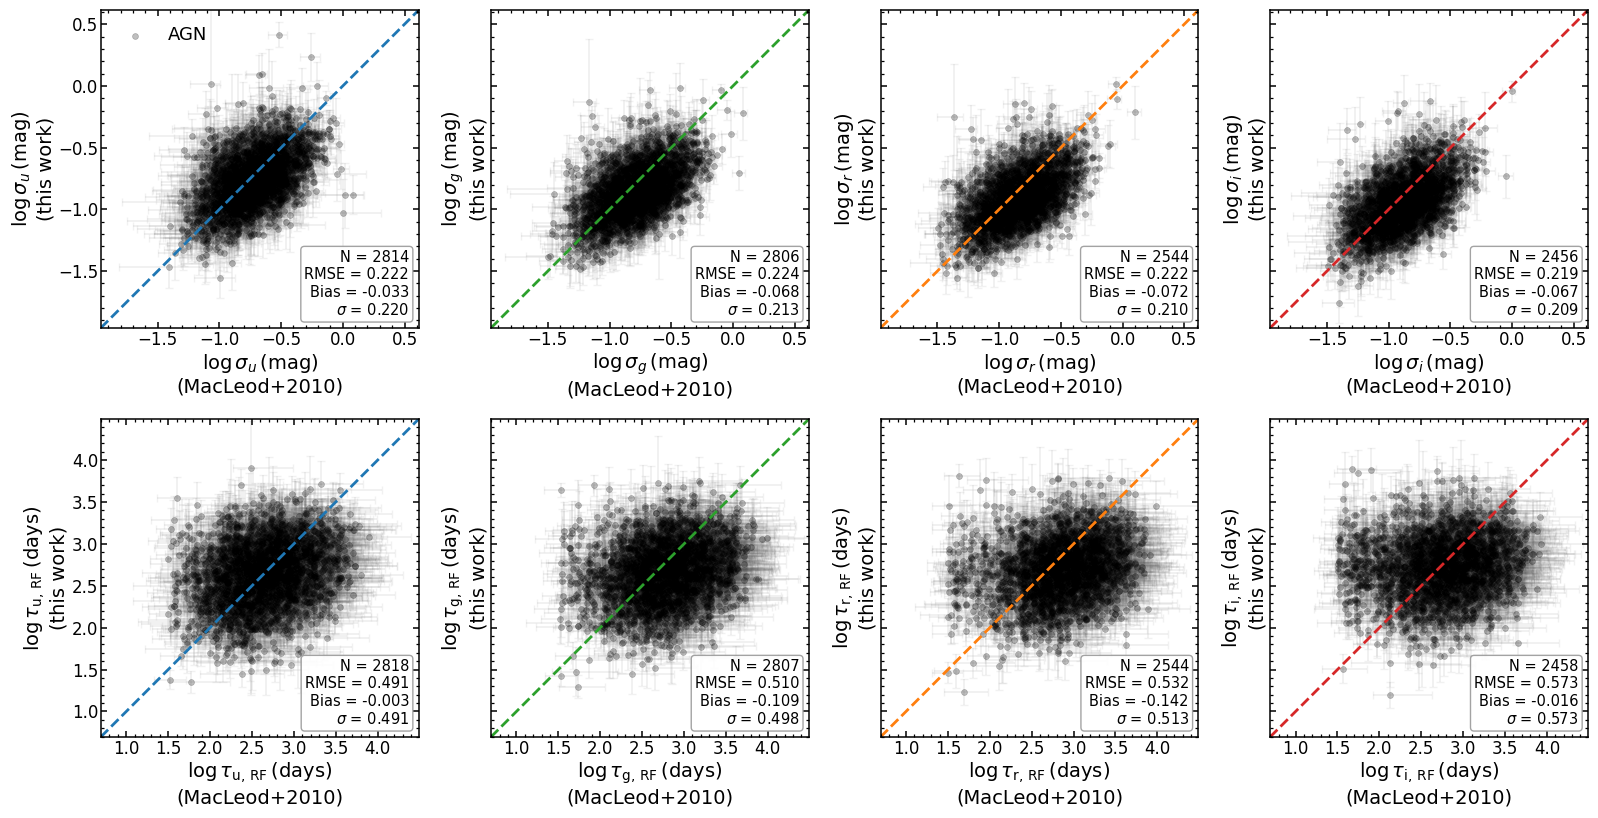

In [ ]:
macleod_sigma_keys = {
    'x': 'macleod_sigma_{band}',
    'y': 'ours_sigma_{band}',
    'xerr': ('macleod_sigma_lo_{band}', 'macleod_sigma_hi_{band}'),
    'xerr_mode': 'bounds',
    'yerr': 'ours_sigma_{band}_err',
    'xlabel': r'$\log\!\,\sigma_<<band>>\,(\mathrm{mag})$' + '\n(MacLeod+2010)',
    'ylabel': r'$\log\!\,\sigma_<<band>>\,(\mathrm{mag})$' + '\n(this work)',
}

macleod_tau_keys = {
    'x': 'macleod_tau_{band}',
    'y': 'ours_tau_{band}',
    'xerr': ('macleod_tau_lo_{band}', 'macleod_tau_hi_{band}'),
    'xerr_mode': 'bounds',
    'yerr': 'ours_tau_{band}_err',
    'xlabel': r'$\log\!\,\tau_{\mathrm{<<band>>},\,\mathrm{RF}}\,(\mathrm{days})$' + '\n(MacLeod+2010)',
    'ylabel': r'$\log\!\,\tau_{\mathrm{<<band>>},\,\mathrm{RF}}\,(\mathrm{days})$' + '\n(this work)',
}

_ = plot_sigma_tau_identity_grid(
    matched_by_band_subcut,
    macleod_sigma_keys,
    macleod_tau_keys,
    bands=('u', 'g', 'r', 'i'),
    output_path='../plots/hubble/diagnostics/tau_identity_this_work_vs_MacLeod2010_ugri_MacLeod2010_tau_cut.pdf',
    style={'point_alpha': 0.25, 'error_alpha': 0.08, 'rasterized': False},
)
plt.show()


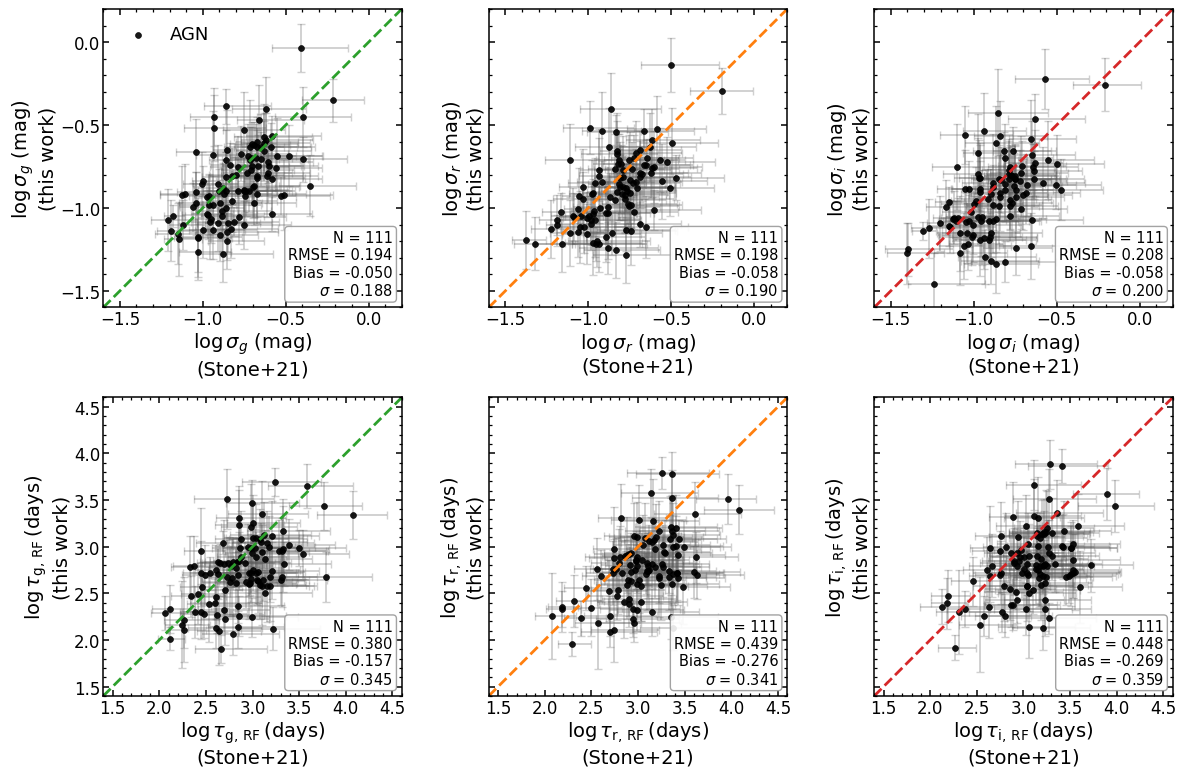

In [ ]:
sigma_keys_raw = {
    'x': 'stone_log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('stone_log_SIGMA_{band}_ERR_L', 'stone_log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log\!\,\sigma_<<band>>$ (mag)' + '\n(Stone+21)',
    'ylabel': r'$\log\!\,\sigma_<<band>>$ (mag)' + '\n(this work)',
}

tau_keys_raw = {
    'x': 'stone_log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('stone_log_TAU_REST_{band}_ERR_L', 'stone_log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log\!\,\tau_{\mathrm{<<band>>},\,\mathrm{RF}}\,(\mathrm{days})$' + '\n(Stone+21)',
    'ylabel': r'$\log\!\,\tau_{\mathrm{<<band>>},\,\mathrm{RF}}\,(\mathrm{days})$' + '\n(this work)',
}

# Load Stone+21 data from FITS and match onto the S82 object ids used by this work
stone_fits_path = Path('../data/Stone2021/TotalDat.fits')
with fits.open(stone_fits_path, memmap=False) as hdul:
    stone_data = hdul[1].data

stone_rows = []
for i in range(len(stone_data)):
    row = {
        'stone_DBID': stone_data['DBID'][i],
        'stone_RA': stone_data['RA'][i],
        'stone_DEC': stone_data['DEC'][i],
        'stone_Z': stone_data['Z'][i],
    }
    for band in ('g', 'r', 'i'):
        row |= {
            f'stone_log_SIGMA_{band}': stone_data[f'log_SIGMA_{band}'][i],
            f'stone_log_SIGMA_{band}_ERR_L': stone_data[f'log_SIGMA_{band}_ERR_L'][i],
            f'stone_log_SIGMA_{band}_ERR_U': stone_data[f'log_SIGMA_{band}_ERR_U'][i],
            f'stone_log_TAU_REST_{band}': stone_data[f'log_TAU_REST_{band}'][i],
            f'stone_log_TAU_REST_{band}_ERR_L': stone_data[f'log_TAU_REST_{band}_ERR_L'][i],
            f'stone_log_TAU_REST_{band}_ERR_U': stone_data[f'log_TAU_REST_{band}_ERR_U'][i],
        }
    stone_rows.append(row)

stone_df = pd.DataFrame(stone_rows)

cat = pd.read_parquet('../data/S82/Catalog.parquet').reset_index()
stone_coords = SkyCoord(ra=stone_df['stone_RA'].to_numpy() * u.deg, dec=stone_df['stone_DEC'].to_numpy() * u.deg)
cat_coords = SkyCoord(ra=cat['RA'].to_numpy() * u.deg, dec=cat['DEC'].to_numpy() * u.deg)
idx, d2d, _ = stone_coords.match_to_catalog_sky(cat_coords)
match_mask = d2d < 1.0 * u.arcsec

stone_df = stone_df.loc[match_mask].copy()
stone_df['object_id'] = cat.iloc[idx[match_mask]]['objectId'].astype(str).to_numpy()
stone_df = stone_df.dropna(axis=0, subset=stone_df.select_dtypes(include=[np.number]).columns)

os.makedirs("figures/appendix/stone_tests", exist_ok=True)
merged_agn_stone = pd.merge(stone_df, df_agn, on='object_id', how='inner', suffixes=('_stone', '_agn'))
plot_sigma_tau_identity_grid(
    merged_agn_stone,
    sigma_keys_raw,
    tau_keys_raw,
    bands=('g', 'r', 'i'),
    figsize=(12, 7.6),
    output_path='figures/appendix/stone_fitted_band_fields.pdf',
    style={'point_alpha': 0.9, 'error_alpha': 0.28, 'rasterized': False},
    sigma_limits=(-1.6, 0.2),
    tau_limits=(1.4, 4.6),
)

stone_r_overlay = merged_agn_stone.rename(columns={
    'stone_log_SIGMA_r': 'stone_sigma_r',
    'stone_log_TAU_REST_r': 'stone_tau_r',
}).copy()


/home/dutra/dev/qvc2/src/qvc/light_curve/plotting_appendix.py:542: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


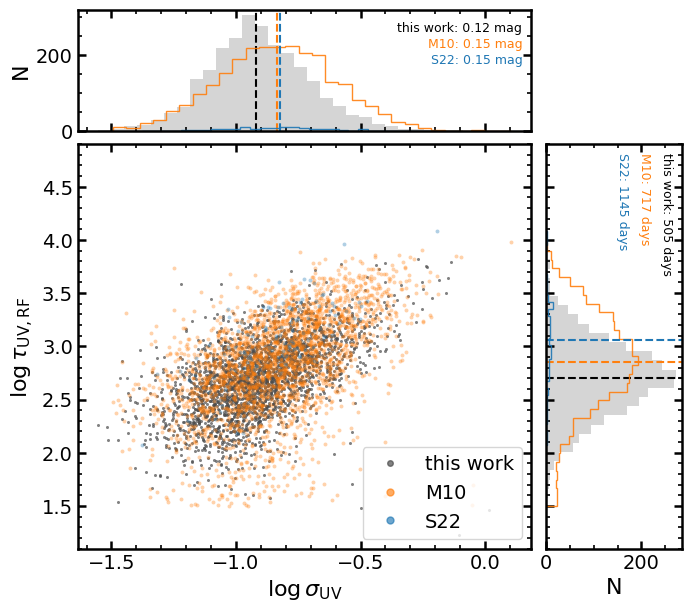

In [9]:
_ = plot_sigma_tau_style_comparison(
    matched_r_subcut,
    matched_r_subcut,
    title=None,
    comparison_overlays=[
        {
            'dataframe': matched_r_subcut,
            'sigma_col': 'macleod_sigma_r',
            'tau_col': 'macleod_tau_r',
            'label': 'M10',
            'color': 'tab:orange',
        },
        {
            'dataframe': stone_r_overlay,
            'sigma_col': 'stone_sigma_r',
            'tau_col': 'stone_tau_r',
            'label': 'S22',
            'color': 'tab:blue',
        },
    ],
)
plt.savefig("../plots/hubble/diagnostics/sigma_tau_comparison_this_work_vs_MacLeod2010_Stone2022_r.pdf", dpi=300)
plt.show()
